<a href="https://colab.research.google.com/github/ridahafeez786/AI_Bootcamp_Lab-work/blob/main/RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Plan of Action:

- Simple QA System
- Dataset (90 samples)
- Build RNN
- Model Inferencing

# What is RNN?
A Recurrent Neural Network (RNN) is a type of neural network designed for processing
sequential data. Unlike traditional feedforward networks, which process inputs independently,
RNNs maintain a memory of previous inputs by using loops in their architecture.
This makes them well-suited for tasks where context and order matter, such as time series
forecasting, speech recognition and text generation.


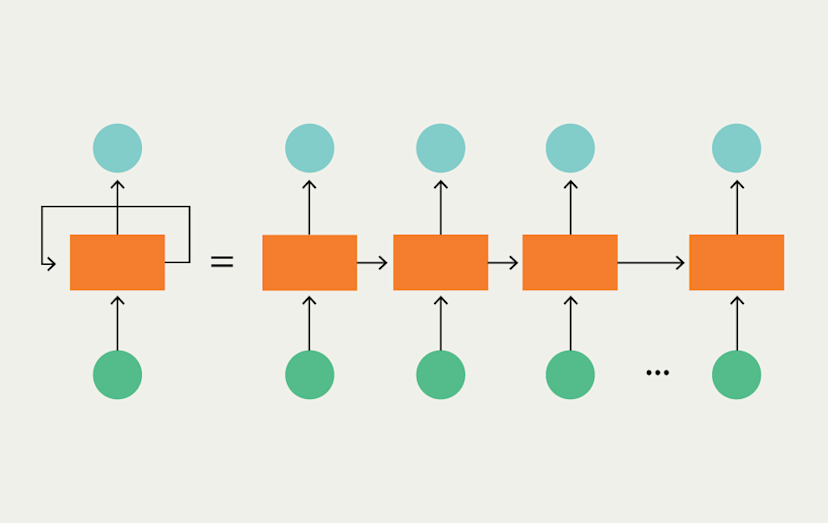

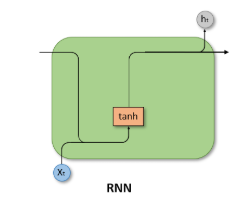

# Difference Between RNN and ANN

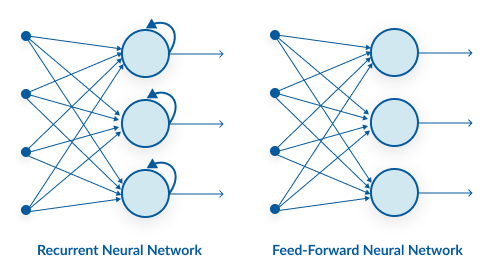

# Steps:
- Load the Dataset
- Build Vocab
- Embedding (English sentenses -> embeddings)
- Build RNN
- Model Training
- Prediction

In [1]:
import pandas as pd
from google.colab import files
uploaded = files.upload()

Saving 100_Unique_QA_Dataset.csv to 100_Unique_QA_Dataset.csv


Load the Dataset

In [2]:
df = pd.read_csv("100_Unique_QA_Dataset.csv")

df.head()

,question,answer
0,What is the capital of France?,Paris
1,What is the capital of Germany?,Berlin
2,Who wrote 'To Kill a Mockingbird'?,Harper-Lee
3,What is the largest planet in our solar system?,Jupiter
4,What is the boiling point of water in Celsius?,100


## Pre Processing

Tokenizetion

In [3]:
# tokenizetion

def tokenizetion(text):
  text = text.lower()
  text = text.replace("?", "")
  text = text.replace("'", "")
  text = text.split()

  return text

In [4]:
tokenizetion("hello, 'I' am Adnan?")

['hello,', 'i', 'am', 'adnan']

Build Vocab

In [5]:
# define vocab (dictionary)

vocab = {'<UNK>':0}

In [6]:
# building vocab

def build_vocab(row):
  tokenized_question = tokenizetion(row['question'])
  tokenized_answer = tokenizetion(row['answer'])

  merged_text = tokenized_question + tokenized_answer

  for token in merged_text:

    if token not in vocab:
      vocab[token] = len(vocab)

In [7]:
df.apply(build_vocab, axis=1)

print('vocab build')

vocab build


In [8]:
# lenght of vocab

len(vocab)

324

In [9]:
# convert words to numerical indices

def text_to_numerical_conversion(text, vocab):

  numerical_text = []

  for token in tokenizetion(text):

    if token in vocab:
      numerical_text.append(vocab[token])
    else:
      numerical_text.append(vocab['<UNK>'])

  return numerical_text

In [10]:
text_to_numerical_conversion("Where is peshawar?", vocab)

[0, 2, 0]

In [11]:
# Custom dataset

import torch
from torch.utils.data import Dataset, DataLoader

class my_dataset(Dataset):

  def __init__(self, df, vocab):
    self.df = df
    self.vocab = vocab

  def __len__(self):

    return self.df.shape[0]

  def __getitem__(self, index):
    numerical_question = text_to_numerical_conversion(self.df.iloc[index]['question'], self.vocab)
    numerical_answer = text_to_numerical_conversion(self.df.iloc[index]['answer'], self.vocab)

    return torch.tensor(numerical_question), torch.tensor(numerical_answer)

In [12]:
# create dataset class instance

dataset = my_dataset(df, vocab)

In [13]:
# dataloader

dataloader = DataLoader(dataset, batch_size=1, shuffle=True)

In [14]:
# now check

for question, answer in dataloader:
  print(question, answer)

tensor([[ 10,   2,  62,  63,   3, 283,   5, 284]]) tensor([[285]])
tensor([[ 78,  79, 261, 151,  14, 262, 153]]) tensor([[36]])
tensor([[1, 2, 3, 4, 5, 6]]) tensor([[7]])
tensor([[ 10, 308,   3, 309, 310]]) tensor([[311]])
tensor([[10, 55,  3, 56,  5, 57]]) tensor([[58]])
tensor([[ 1,  2,  3, 33, 34,  5, 35]]) tensor([[36]])
tensor([[10, 75, 76]]) tensor([[77]])
tensor([[ 42, 137, 118,   3, 247,   5, 248]]) tensor([[249]])
tensor([[ 78,  79, 129,  81,  19,   3,  21,  22]]) tensor([[36]])
tensor([[  1,   2,   3,   4,   5, 286]]) tensor([[287]])
tensor([[ 1,  2,  3, 69,  5,  3, 70, 71]]) tensor([[72]])
tensor([[ 1,  2,  3, 50, 51, 19,  3, 45]]) tensor([[52]])
tensor([[ 42,  18,   2,   3, 281,  12,   3, 282]]) tensor([[205]])
tensor([[ 10, 140,   3, 141, 142,  12, 143,  83,   3, 144]]) tensor([[145]])
tensor([[42, 43, 44, 45, 46, 47, 48]]) tensor([[49]])
tensor([[ 10,  75,   3, 296,  19, 297]]) tensor([[298]])
tensor([[ 1,  2,  3, 17, 18, 19, 20, 21, 22]]) tensor([[23]])
tensor([[ 42, 125

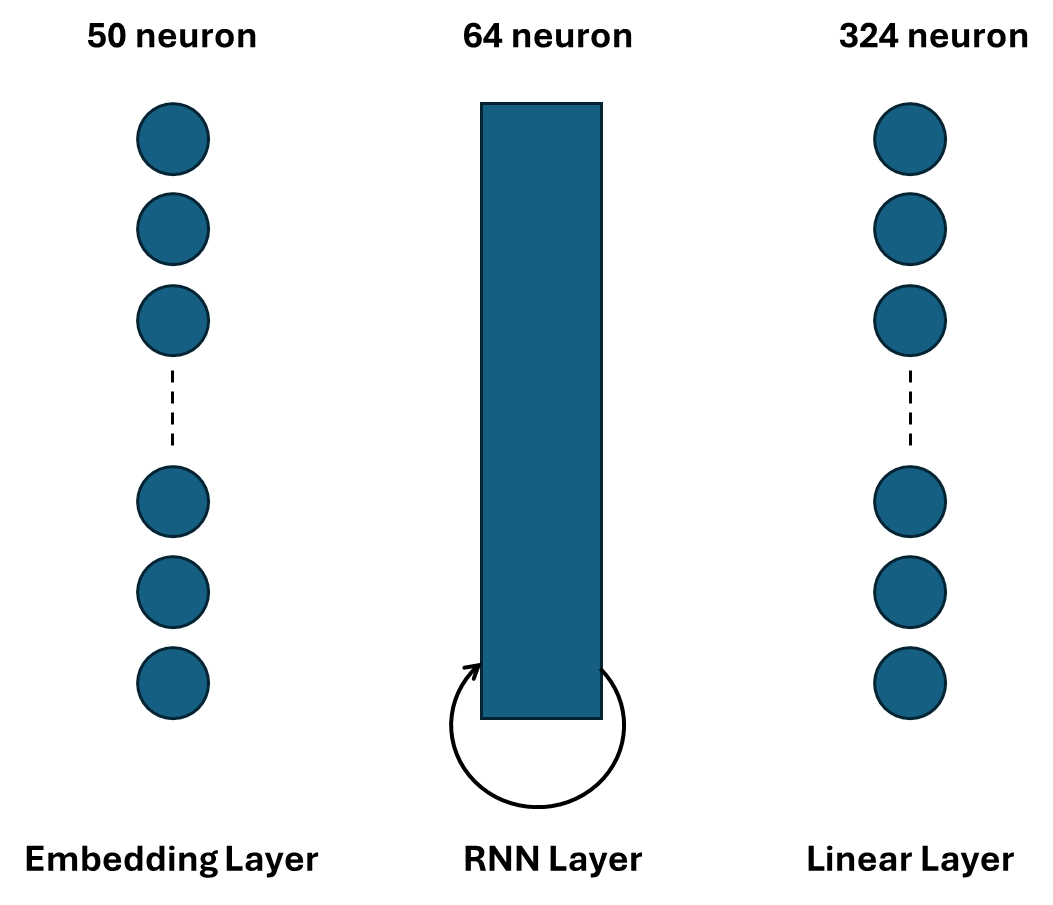

In [15]:
# create model

import torch.nn as nn


class rnn_model(nn.Module):

  def __init__(self, vocab_size):

    super().__init__()

    self.embedding = nn.Embedding(vocab_size, embedding_dim=50)
    self.rnn = nn.RNN(50, 64, batch_first=True)
    self.fc = nn.Linear(64, vocab_size)

  def forward(self, text):
    embedded_text = self.embedding(text)
    hidden_state, final_out = self.rnn(embedded_text)
    output = self.fc(final_out.squeeze(0))

    return output

In [16]:
a = nn.Embedding(len(vocab), embedding_dim=50)
b = nn.RNN(50, 64,batch_first=True)
c = nn.Linear(64, len(vocab))

In [17]:
x = dataset[0][0].reshape(1, 6)
print("shape of x :", x.shape)

shape of x : torch.Size([1, 6])


In [18]:
y = a(x)
print("shape of y:", y.shape)

shape of y: torch.Size([1, 6, 50])


In [19]:
z1, z2 = b(y)
print("shpae of z :", z2.shape)
print("shpae of z :", z1.shape)

shpae of z : torch.Size([1, 1, 64])
shpae of z : torch.Size([1, 6, 64])


In [20]:
final = c(z2.squeeze(0))
print("shape of final :", final.shape)

shape of final : torch.Size([1, 324])


In [21]:
# create model instance

model = rnn_model(len(vocab))

In [22]:
# Hyperparameters

learning_rate = 0.01

epochs = 25

loss_function = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [23]:
# training loop

for epoch in range(epochs):

  total_loss = 0

  for question, answer in dataloader:

    # forward pass
    outputs = model(question)

    # loss
    loss = loss_function(outputs, answer[0])

    # clean gradient
    optimizer.zero_grad()

    # backward pass
    loss.backward()

    # update parameters
    optimizer.step()

    total_loss = total_loss + loss.item()

  print(f"Epoch :{epoch+1}, Loss :{total_loss}")

Epoch :1, Loss :538.4756169319153
Epoch :2, Loss :328.4755896627903
Epoch :3, Loss :153.57478220760822
Epoch :4, Loss :76.07381824590266
Epoch :5, Loss :48.96546049742028
Epoch :6, Loss :41.93291922425851
Epoch :7, Loss :26.91734455898404
Epoch :8, Loss :19.944516588468105
Epoch :9, Loss :10.282191004836932
Epoch :10, Loss :13.73824520315975
Epoch :11, Loss :9.480750506278127
Epoch :12, Loss :15.21914997836575
Epoch :13, Loss :16.126243008766323
Epoch :14, Loss :10.755059744231403
Epoch :15, Loss :12.417591884732246
Epoch :16, Loss :7.530015399679542
Epoch :17, Loss :10.412325367098674
Epoch :18, Loss :9.903972965665162
Epoch :19, Loss :10.317158360267058
Epoch :20, Loss :8.052070577978157
Epoch :21, Loss :4.494812043849379
Epoch :22, Loss :5.626921200542711
Epoch :23, Loss :5.000320362159982
Epoch :24, Loss :5.681695768493228
Epoch :25, Loss :8.535185940912925


In [ ]:
model.eval()

In [24]:
# prediction

def prediction(model, question, threshold=0.5):

  # convert question to numerical
  numerical_question = text_to_numerical_conversion(question, vocab)

  # tensor
  question_to_tensor = torch.tensor(numerical_question).unsqueeze(0)

  # input to model
  output = model(question_to_tensor)

  # convert logit to probs
  probs = torch.nn.functional.softmax(output, dim=1)

  # find index of max probs
  value, predicted_index = torch.max(probs, 1)

  if value < threshold:
    print("I don't know")

  else:
    print(list(vocab.keys())[predicted_index])


In [29]:
prediction(model, "What is the capital of France?")

paris
